<a href="https://colab.research.google.com/github/mayuresh-tungare/c3-project/blob/main/ETL_Traffic_Data_Analysis_Mayuresh_Tungare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

Install Required Libraries

In [3]:
# Import and install the necessary libraries as needed
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date
!pip install --quiet pyspark==4.0.0 pandas==2.2.2

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [4]:
df_victims = pd.read_csv('https://drive.google.com/uc?export=download&id=1-gaGpJru2S1dih_37ukWAtbvlDDj4QIi')
df_parties = pd.read_csv('https://drive.google.com/uc?export=download&id=1Ka32yYFTYyHzIW-D_3TljL9vpwgUeQCa')
df_collisions = pd.read_csv('https://drive.google.com/uc?export=download&id=1C0drOYXMRqyepZ_ogmwfLkDTkMT8kzAf')
df_case_ids = pd.read_csv('https://drive.google.com/uc?export=download&id=1h4d0sXgrHcspHLlqrLh_fsTLXWzeH32P')

### Using `gdown` to download large files from Google Drive

When `pd.read_csv` struggles with large Google Drive files, often due to virus scan warnings or non-direct download links, `gdown` is a useful tool. It simplifies downloading files directly from Google Drive using their file IDs.

In [5]:
# Install gdown if you haven't already
!pip install --quiet gdown

In [6]:
import gdown
import pandas as pd

# Define the Google Drive file IDs and desired output filenames
# Note: These IDs are extracted from your original 'uc?export=download&id=' links.

victims_file_id = '1-gaGpJru2S1dih_37ukWAtbvlDDj4QIi'
parties_file_id = '1Ka32yYFTYyHzIW-D_3TljL9vpwgUeQCa'
collisions_file_id = '1C0drOYXMRqyepZ_ogmwfLkDTkMT8kzAf'
case_ids_file_id = '1h4d0sXgrHcspHLlqrLh_fsTLXWzeH32P'

victims_output = 'sample_victims.csv'
parties_output = 'sample_parties.csv'
collisions_output = 'sample_collisions.csv'
case_ids_output = 'sample_case_ids.csv'

# Download the files using gdown
print(f"Downloading {victims_output}...")
gdown.download(id=victims_file_id, output=victims_output, quiet=True)
print(f"Downloading {parties_output}...")
gdown.download(id=parties_file_id, output=parties_output, quiet=True)
print(f"Downloading {collisions_output}...")
gdown.download(id=collisions_file_id, output=collisions_output, quiet=True)
print(f"Downloading {case_ids_output}...")
gdown.download(id=case_ids_file_id, output=case_ids_output, quiet=True)

# Load the downloaded CSVs into pandas DataFrames
df_victims = pd.read_csv(victims_output)
df_parties = pd.read_csv(parties_output)
df_collisions = pd.read_csv(collisions_output)
df_case_ids = pd.read_csv(case_ids_output)

print("All DataFrames loaded successfully!")

All DataFrames loaded successfully!


In [7]:
# Display head of each DataFrame to confirm
print("df_victims head:")
display(df_victims.head())
print("\ndf_parties head:")
display(df_parties.head())
print("\ndf_collisions head:")
display(df_collisions.head())
print("\ndf_case_ids head:")
display(df_case_ids.head())

df_victims head:


,id,case_id,party_number,victim_role,victim_sex,victim_age,victim_degree_of_injury,victim_seating_position,victim_safety_equipment_1,victim_safety_equipment_2,victim_ejected
0,2166324,6324923.0,1,driver,male,62.0,complaint of pain,driver,air bag not deployed,lap/shoulder harness used,not ejected
1,779470,761473.0,1,passenger,male,25.0,no injury,passenger seat 3,lap/shoulder harness used,NaN,not ejected
2,742636,723123.0,1,driver,NaN,31.0,complaint of pain,driver,lap/shoulder harness used,NaN,not ejected
3,2412638,2276798.0,1,driver,female,51.0,complaint of pain,driver,air bag not deployed,lap/shoulder harness used,not ejected
4,4121224,90110954.0,1,passenger,female,4.0,no injury,passenger seat 4,not required,child restraint in vehicle used,not ejected



df_parties head:


,id,case_id,party_number,party_type,at_fault,party_sex,party_age,party_sobriety,direction_of_travel,party_safety_equipment_1,...,other_associate_factor_1,party_number_killed,party_number_injured,movement_preceding_collision,vehicle_year,vehicle_make,statewide_vehicle_type,chp_vehicle_type_towing,chp_vehicle_type_towed,party_race
0,1292305,4.843348e+06,1,driver,1,male,28.0,had not been drinking,south,lap/shoulder harness used,...,inattention,0,0,making right turn,1974.0,chevrolet,passenger car,NaN,NaN,NaN
1,3252679,5.965300e+06,2,driver,0,male,53.0,had not been drinking,south,air bag not deployed,...,entering/leaving ramp,0,0,proceeding straight,2000.0,toyota,passenger car,"passenger car, station",00,hispanic
2,5367929,7.110929e+06,2,driver,0,female,22.0,had not been drinking,west,air bag not deployed,...,none apparent,0,0,proceeding straight,2008.0,mazda,passenger car,"passenger car, station",NaN,hispanic
3,1482458,4.945119e+06,2,pedestrian,0,female,52.0,had not been drinking,south,NaN,...,none apparent,0,1,proceeding straight,NaN,NaN,pedestrian,pedestrian,00,hispanic
4,16036906,9.250011e+18,2,driver,0,female,34.0,had not been drinking,south,lap/shoulder harness used,...,none apparent,0,0,proceeding straight,1976.0,ford,passenger car,"passenger car, station",00,NaN



df_collisions head:


,case_id,jurisdiction,officer_id,reporting_district,chp_shift,population,county_city_location,county_location,special_condition,beat_type,...,pedestrian_injured_count,bicyclist_killed_count,bicyclist_injured_count,motorcyclist_killed_count,motorcyclist_injured_count,latitude,longitude,collision_date,collision_time,process_date
0,8000993.0,1942.0,39335,1676,not chp,>250000,1942,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2016-03-20,16:30:00,2016-03-30
1,4232117.0,3008.0,1284,Z2,not chp,100000 to 250000,3008,orange,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2009-04-13,18:24:00,2009-11-30
2,91389627.0,9285.0,019223,NaN,1400 thru 2159,unincorporated,5800,yuba,0.0,chp county roadline,...,0,0,0,0,0.0,39.12512,-121.57211,2021-01-09,18:15:00,2021-01-18
3,3589817.0,3610.0,50586,3610,not chp,100000 to 250000,3610,san bernardino,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2007-06-16,21:50:00,2008-03-11
4,9111695.0,1900.0,649318,0261,not chp,25000 to 50000,1917,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2020-04-14,17:56:00,2020-08-03



df_case_ids head:


,case_id,db_year
0,90017156.0,2021
1,4078685.0,2021
2,90588783.0,2021
3,3351919.0,2018
4,632208.0,2018


#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [8]:
#Display Schema & Sample Data
df_victims.head()
df_parties.head()
df_collisions.head()
df_case_ids.head()

,case_id,db_year
0,90017156.0,2021
1,4078685.0,2021
2,90588783.0,2021
3,3351919.0,2018
4,632208.0,2018


##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [9]:
#Check for Missing Values
print("Missing values in df_victims:")
print(df_victims.isnull().sum())
print("\nMissing values in df_parties:")
print(df_parties.isnull().sum())
print("\nMissing values in df_collisions:")
print(df_collisions.isnull().sum())
print("\nMissing values in df_case_ids:")
print(df_case_ids.isnull().sum())

Missing values in df_victims:
id                                0
case_id                           0
party_number                      0
victim_role                       1
victim_sex                    24041
victim_age                    32145
victim_degree_of_injury           0
victim_seating_position        1913
victim_safety_equipment_1     55215
victim_safety_equipment_2    310220
victim_ejected                 4272
dtype: int64

Missing values in df_parties:
id                                   0
case_id                              0
party_number                         0
party_type                        4395
at_fault                             0
party_sex                       249269
party_age                       290783
party_sobriety                   55663
direction_of_travel              52377
party_safety_equipment_1        314883
party_safety_equipment_2        699581
financial_responsibility        152613
cellphone_in_use                568197
cellphone_use_type     

In [10]:
# Drop Sparse Columns

def drop_sparse_columns(df, df_name, threshold=0.7):
    print(f"\nProcessing {df_name}...")
    print(f"Original shape of {df_name}: {df.shape}")

    # Calculate the percentage of missing values for each column
    missing_percentages = df.isnull().sum() / len(df)

    # Identify columns to drop based on the threshold
    sparse_columns = missing_percentages[missing_percentages > threshold].index.tolist()

    if sparse_columns:
        print(f"Dropping sparse columns from {df_name}: {sparse_columns}")
        df = df.drop(columns=sparse_columns)
    else:
        print(f"No sparse columns found in {df_name} above the {threshold*100}% threshold.")

    print(f"New shape of {df_name}: {df.shape}")
    return df

# Apply the function to each DataFrame
df_victims = drop_sparse_columns(df_victims, 'df_victims')
df_parties = drop_sparse_columns(df_parties, 'df_parties')
df_collisions = drop_sparse_columns(df_collisions, 'df_collisions')
df_case_ids = drop_sparse_columns(df_case_ids, 'df_case_ids')


Processing df_victims...
Original shape of df_victims: (963933, 11)
No sparse columns found in df_victims above the 70.0% threshold.
New shape of df_victims: (963933, 11)

Processing df_parties...
Original shape of df_parties: (1866917, 24)
No sparse columns found in df_parties above the 70.0% threshold.
New shape of df_parties: (1866917, 24)

Processing df_collisions...
Original shape of df_collisions: (935791, 65)
Dropping sparse columns from df_collisions: ['caltrans_county', 'location_type', 'side_of_highway', 'latitude', 'longitude']
New shape of df_collisions: (935791, 60)

Processing df_case_ids...
Original shape of df_case_ids: (942433, 2)
No sparse columns found in df_case_ids above the 70.0% threshold.
New shape of df_case_ids: (942433, 2)


In [15]:
# Handle Missing Values

# Impute numerical columns with median and categorical columns with mode
def impute_missing_values(df, df_name):
    print(f"\nHandling missing values for {df_name}...")
    for column in df.columns:
        if df[column].isnull().any():
            if pd.api.types.is_numeric_dtype(df[column]):
                median_val = df[column].median()
                df[column] = df[column].fillna(median_val)
                print(f"  Filled missing values in numerical column '{column}' with median: {median_val}")
            else:
                mode_val = df[column].mode()[0]
                df[column] = df[column].fillna(mode_val)
                print(f"  Filled missing values in categorical column '{column}' with mode: {mode_val}")
    return df

# Apply imputation to each DataFrame
df_victims = impute_missing_values(df_victims, 'df_victims')
df_parties = impute_missing_values(df_parties, 'df_parties')
df_collisions = impute_missing_values(df_collisions, 'df_collisions')
# df_case_ids has no missing values, so no need to process it again here

print("\nMissing values after imputation:")
print("Missing values in df_victims:")
print(df_victims.isnull().sum())
print("\nMissing values in df_parties:")
print(df_parties.isnull().sum())
print("\nMissing values in df_collisions:")
print(df_collisions.isnull().sum())
print("\nMissing values in df_case_ids:")
print(df_case_ids.isnull().sum())


Handling missing values for df_victims...
  Filled missing values in categorical column 'victim_role' with mode: passenger
  Filled missing values in categorical column 'victim_sex' with mode: female
  Filled missing values in numerical column 'victim_age' with median: 27.0
  Filled missing values in categorical column 'victim_seating_position' with mode: driver
  Filled missing values in categorical column 'victim_safety_equipment_1' with mode: air bag not deployed
  Filled missing values in categorical column 'victim_safety_equipment_2' with mode: lap/shoulder harness used
  Filled missing values in categorical column 'victim_ejected' with mode: not ejected

Handling missing values for df_parties...
  Filled missing values in categorical column 'party_type' with mode: driver
  Filled missing values in categorical column 'party_sex' with mode: male
  Filled missing values in numerical column 'party_age' with median: 36.0
  Filled missing values in categorical column 'party_sobriety' 

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [16]:
# Remove Duplicates

print("Original shapes before dropping duplicates:")
print(f"df_victims: {df_victims.shape}")
print(f"df_parties: {df_parties.shape}")
print(f"df_collisions: {df_collisions.shape}")
print(f"df_case_ids: {df_case_ids.shape}")

df_victims = df_victims.drop_duplicates()
df_parties = df_parties.drop_duplicates()
df_collisions = df_collisions.drop_duplicates()
df_case_ids = df_case_ids.drop_duplicates()

print("\nShapes after dropping duplicates:")
print(f"df_victims: {df_victims.shape}")
print(f"df_parties: {df_parties.shape}")
print(f"df_collisions: {df_collisions.shape}")
print(f"df_case_ids: {df_case_ids.shape}")

Original shapes before dropping duplicates:
df_victims: (963933, 11)
df_parties: (1866917, 24)
df_collisions: (935791, 60)
df_case_ids: (942433, 2)

Shapes after dropping duplicates:
df_victims: (963933, 11)
df_parties: (1866917, 24)
df_collisions: (935791, 60)
df_case_ids: (942388, 2)


In [17]:
#Detect Outliers using IQR

# List of numerical columns to check for outliers
numerical_cols_collisions = df_collisions.select_dtypes(include=['number']).columns

print("IQR for Numerical Columns in df_collisions:")
for col in numerical_cols_collisions:
    Q1 = df_collisions[col].quantile(0.25)
    Q3 = df_collisions[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Column '{col}': Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")

IQR for Numerical Columns in df_collisions:
Column 'case_id': Q1=2659866.50, Q3=8743403.50, IQR=6083537.00
Column 'jurisdiction': Q1=1976.00, Q3=9525.00, IQR=7549.00
Column 'county_city_location': Q1=1941.00, Q3=3705.00, IQR=1764.00
Column 'special_condition': Q1=0.00, Q3=0.00, IQR=0.00
Column 'distance': Q1=0.00, Q3=488.00, IQR=488.00
Column 'intersection': Q1=0.00, Q3=0.00, IQR=0.00
Column 'state_highway_indicator': Q1=0.00, Q3=1.00, IQR=1.00
Column 'caltrans_district': Q1=7.00, Q3=7.00, IQR=0.00
Column 'state_route': Q1=78.00, Q3=78.00, IQR=0.00
Column 'postmile': Q1=12.96, Q3=12.96, IQR=0.00
Column 'tow_away': Q1=0.00, Q3=1.00, IQR=1.00
Column 'killed_victims': Q1=0.00, Q3=0.00, IQR=0.00
Column 'injured_victims': Q1=0.00, Q3=1.00, IQR=1.00
Column 'party_count': Q1=2.00, Q3=2.00, IQR=0.00
Column 'pcf_violation': Q1=21802.00, Q3=22350.00, IQR=548.00
Column 'chp_road_type': Q1=0.00, Q3=0.00, IQR=0.00
Column 'pedestrian_collision': Q1=0.00, Q3=0.00, IQR=0.00
Column 'bicycle_collision':

In [26]:
# Initialize SparkSession if not already initialized
try:
    spark
except NameError:
    from pyspark.sql import SparkSession
    spark = SparkSession.builder \
        .appName("TrafficCollisionAnalysis") \
        .config("spark.driver.memory", "8g") \
        .getOrCreate()
    print("SparkSession initialized.")

# Convert Pandas DataFrames to PySpark DataFrames
spark_df_victims = spark.createDataFrame(df_victims)
spark_df_parties = spark.createDataFrame(df_parties)
spark_df_collisions = spark.createDataFrame(df_collisions)
spark_df_case_ids = spark.createDataFrame(df_case_ids)

print("Pandas DataFrames converted to PySpark DataFrames.")

# Display schemas to verify
print("\nSpark DataFrame Schemas:")
spark_df_victims.printSchema()
spark_df_parties.printSchema()
spark_df_collisions.printSchema()
spark_df_case_ids.printSchema()

Pandas DataFrames converted to PySpark DataFrames.

Spark DataFrame Schemas:
root
 |-- id: long (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: long (nullable = true)
 |-- victim_role: string (nullable = true)
 |-- victim_sex: string (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_degree_of_injury: string (nullable = true)
 |-- victim_seating_position: string (nullable = true)
 |-- victim_safety_equipment_1: string (nullable = true)
 |-- victim_safety_equipment_2: string (nullable = true)
 |-- victim_ejected: string (nullable = true)

root
 |-- id: long (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: long (nullable = true)
 |-- party_type: string (nullable = true)
 |-- at_fault: long (nullable = true)
 |-- party_sex: string (nullable = true)
 |-- party_age: double (nullable = true)
 |-- party_sobriety: string (nullable = true)
 |-- direction_of_travel: string (nullable = true)
 |-- party_safety_equipment_1:

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [21]:
# Identify Outliers using IQR

def identify_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("Outlier Analysis for df_collisions (based on IQR):")
for col in numerical_cols_collisions:
    outliers_found = identify_outliers_iqr(df_collisions, col)
    if not outliers_found.empty:
        print(f"Column '{col}': {len(outliers_found)} outliers found.")
    else:
        print(f"Column '{col}': No outliers found.")

Outlier Analysis for df_collisions (based on IQR):
Column 'case_id': 185332 outliers found.
Column 'jurisdiction': No outliers found.
Column 'county_city_location': No outliers found.
Column 'special_condition': 3558 outliers found.
Column 'distance': 104977 outliers found.
Column 'intersection': 215686 outliers found.
Column 'state_highway_indicator': No outliers found.
Column 'caltrans_district': 216188 outliers found.
Column 'state_route': 285567 outliers found.
Column 'postmile': 286984 outliers found.
Column 'tow_away': No outliers found.
Column 'killed_victims': No outliers found.
Column 'injured_victims': 33313 outliers found.
Column 'party_count': 298314 outliers found.
Column 'pcf_violation': 7883 outliers found.
Column 'chp_road_type': 175413 outliers found.
Column 'pedestrian_collision': 26896 outliers found.
Column 'bicycle_collision': 25538 outliers found.
Column 'motorcycle_collision': 27087 outliers found.
Column 'truck_collision': 54322 outliers found.
Column 'not_priva

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [22]:
# Encode Categorical Variables for df_victims
from pyspark.ml.feature import StringIndexer
def string_index_dataframe(spark_df, df_name):
    print(f"\nApplying String Indexing to {df_name}...")
    categorical_cols = [col_name for col_name, dtype in spark_df.dtypes if dtype == 'string']

    indexed_df = spark_df
    for col_name in categorical_cols:
        indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_indexed", handleInvalid="keep")
        indexed_df = indexer.fit(indexed_df).transform(indexed_df)
        # Optionally, drop the original string column if not needed
        indexed_df = indexed_df.drop(col_name)
        indexed_df = indexed_df.withColumnRenamed(col_name + "_indexed", col_name)

    print(f"String Indexing completed for {df_name}.")
    return indexed_df

# String Indexing for Categorical Columns
# Apply string indexing to only spark_df_victims
spark_df_victims_indexed = string_index_dataframe(spark_df_victims, 'spark_df_victims')

print("\nSchemas after String Indexing (only for spark_df_victims):")
spark_df_victims_indexed.printSchema()


Applying String Indexing to spark_df_victims...
String Indexing completed for spark_df_victims.

Schemas after String Indexing (only for spark_df_victims):
root
 |-- id: long (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: long (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_role: double (nullable = false)
 |-- victim_sex: double (nullable = false)
 |-- victim_degree_of_injury: double (nullable = false)
 |-- victim_seating_position: double (nullable = false)
 |-- victim_safety_equipment_1: double (nullable = false)
 |-- victim_safety_equipment_2: double (nullable = false)
 |-- victim_ejected: double (nullable = false)



In [27]:
# Encode Categorical Variables for df_parties
from pyspark.ml.feature import StringIndexer
def string_index_dataframe(spark_df, df_name):
    print(f"\nApplying String Indexing to {df_name}...")
    categorical_cols = [col_name for col_name, dtype in spark_df.dtypes if dtype == 'string']

    indexed_df = spark_df
    for col_name in categorical_cols:
        indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_indexed", handleInvalid="keep")
        indexed_df = indexer.fit(indexed_df).transform(indexed_df)
        # Optionally, drop the original string column if not needed
        indexed_df = indexed_df.drop(col_name)
        indexed_df = indexed_df.withColumnRenamed(col_name + "_indexed", col_name)

    print(f"String Indexing completed for {df_name}.")
    return indexed_df

# String Indexing for Categorical Columns
# Apply string indexing to only spark_df_parties
spark_df_parties_indexed = string_index_dataframe(spark_df_parties, 'spark_df_parties')

print("\nSchemas after String Indexing (only for spark_df_parties):")
spark_df_parties_indexed.printSchema()


Applying String Indexing to spark_df_parties...
String Indexing completed for spark_df_parties.

Schemas after String Indexing (only for spark_df_parties):
root
 |-- id: long (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: long (nullable = true)
 |-- at_fault: long (nullable = true)
 |-- party_age: double (nullable = true)
 |-- cellphone_in_use: double (nullable = true)
 |-- party_number_killed: long (nullable = true)
 |-- party_number_injured: long (nullable = true)
 |-- vehicle_year: double (nullable = true)
 |-- party_type: double (nullable = false)
 |-- party_sex: double (nullable = false)
 |-- party_sobriety: double (nullable = false)
 |-- direction_of_travel: double (nullable = false)
 |-- party_safety_equipment_1: double (nullable = false)
 |-- party_safety_equipment_2: double (nullable = false)
 |-- financial_responsibility: double (nullable = false)
 |-- cellphone_use_type: double (nullable = false)
 |-- other_associate_factor_1: double (nullable =

In [28]:
# Encode Categorical Variables for df_collisions
from pyspark.ml.feature import StringIndexer
def string_index_dataframe(spark_df, df_name):
    print(f"\nApplying String Indexing to {df_name}...")
    categorical_cols = [col_name for col_name, dtype in spark_df.dtypes if dtype == 'string']

    indexed_df = spark_df
    for col_name in categorical_cols:
        indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_indexed", handleInvalid="keep")
        indexed_df = indexer.fit(indexed_df).transform(indexed_df)
        # Optionally, drop the original string column if not needed
        indexed_df = indexed_df.drop(col_name)
        indexed_df = indexed_df.withColumnRenamed(col_name + "_indexed", col_name)

    print(f"String Indexing completed for {df_name}.")
    return indexed_df

# String Indexing for Categorical Columns
# Apply string indexing to only spark_df_collisions
spark_df_collisions_indexed = string_index_dataframe(spark_df_collisions, 'spark_df_collisions')

print("\nSchemas after String Indexing (only for spark_df_collisions):")
spark_df_victims_indexed.printSchema()


Applying String Indexing to spark_df_collisions...
String Indexing completed for spark_df_collisions.

Schemas after String Indexing (only for spark_df_collisions):
root
 |-- id: long (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: long (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_role: double (nullable = false)
 |-- victim_sex: double (nullable = false)
 |-- victim_degree_of_injury: double (nullable = false)
 |-- victim_seating_position: double (nullable = false)
 |-- victim_safety_equipment_1: double (nullable = false)
 |-- victim_safety_equipment_2: double (nullable = false)
 |-- victim_ejected: double (nullable = false)



In [30]:
# Encode Categorical Variables for df_case_ids
from pyspark.ml.feature import StringIndexer
def string_index_dataframe(spark_df, df_name):
    print(f"\nApplying String Indexing to {df_name}...")
    categorical_cols = [col_name for col_name, dtype in spark_df.dtypes if dtype == 'string']

    indexed_df = spark_df
    for col_name in categorical_cols:
        indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_indexed", handleInvalid="keep")
        indexed_df = indexer.fit(indexed_df).transform(indexed_df)
        # Optionally, drop the original string column if not needed
        indexed_df = indexed_df.drop(col_name)
        indexed_df = indexed_df.withColumnRenamed(col_name + "_indexed", col_name)

    print(f"String Indexing completed for {df_name}.")
    return indexed_df

# String Indexing for Categorical Columns
# Apply string indexing to only spark_df_case_ids
spark_df_case_ids_indexed = string_index_dataframe(spark_df_case_ids, 'spark_df_case_ids')

print("\nSchemas after String Indexing (only for spark_df_case_ids):")
spark_df_case_ids_indexed.printSchema()


Applying String Indexing to spark_df_case_ids...
String Indexing completed for spark_df_case_ids.

Schemas after String Indexing (only for spark_df_case_ids):
root
 |-- case_id: double (nullable = true)
 |-- db_year: long (nullable = true)



In [32]:
from pyspark.sql.functions import col

# Function to clean column names (lowercase, replace spaces/special chars with underscores)
def clean_spark_df_column_names(df):
    new_columns = []
    for c in df.columns:
        new_c = c.lower().replace(' ', '_').replace('-', '_').replace('.', '').replace('/', '_')
        new_columns.append(new_c)
    return df.toDF(*new_columns)

# Apply cleaning to all Spark DataFrames
spark_df_victims_indexed = clean_spark_df_column_names(spark_df_victims_indexed)
spark_df_parties_indexed = clean_spark_df_column_names(spark_df_parties_indexed)
spark_df_collisions_indexed = clean_spark_df_column_names(spark_df_collisions_indexed)
spark_df_case_ids_indexed = clean_spark_df_column_names(spark_df_case_ids_indexed)

print("Column names standardized for all indexed Spark DataFrames.")

# Display schema for one DataFrame to verify
print("\nSchema for spark_df_collisions_indexed after renaming:")
spark_df_collisions_indexed.printSchema()

Column names standardized for all indexed Spark DataFrames.

Schema for spark_df_collisions_indexed after renaming:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- county_city_location: long (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- distance: double (nullable = true)
 |-- intersection: double (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_district: double (nullable = true)
 |-- state_route: double (nullable = true)
 |-- postmile: double (nullable = true)
 |-- tow_away: double (nullable = true)
 |-- killed_victims: double (nullable = true)
 |-- injured_victims: double (nullable = true)
 |-- party_count: double (nullable = true)
 |-- pcf_violation: double (nullable = true)
 |-- chp_road_type: double (nullable = true)
 |-- pedestrian_collision: long (nullable = true)
 |-- bicycle_collision: long (nullable = true)
 |-- motorcycle_collision: long (nullable = true)
 |-- truck_co

### Reorder Columns

Column reordering helps to organize data more logically, especially when certain columns are more frequently accessed or serve as primary identifiers. Here, we'll reorder the `spark_df_collisions_indexed` DataFrame to place `case_id`, `collision_date`, and `collision_time` at the beginning.

In [33]:
# Reorder columns in spark_df_collisions_indexed

# Define the desired order for the leading columns
leading_columns = ["case_id", "collision_date", "collision_time"]

# Get all other columns, excluding the leading ones
other_columns = [col for col in spark_df_collisions_indexed.columns if col not in leading_columns]

# Combine them to form the new column order
new_column_order = leading_columns + other_columns

# Select the DataFrame with the new column order
spark_df_collisions_indexed = spark_df_collisions_indexed.select(new_column_order)

print("Columns reordered for spark_df_collisions_indexed. Displaying the first few rows to verify:")
spark_df_collisions_indexed.show(5)

Columns reordered for spark_df_collisions_indexed. Displaying the first few rows to verify:
+-----------+--------------+--------------+------------+--------------------+-----------------+--------+------------+-----------------------+-----------------+-----------+--------+--------+--------------+---------------+-----------+-------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-------------------------+--------------------------+----------+------------------+---------+----------+---------------+---------+-------------+--------------+-----------+------------+--------------+---------+---------+------------------+------------------------+----------------------+------------------------+-----------+-----------------+---------------------------+--------

In [34]:
print("\n--- Final Cleaned DataFrames ---")

print("\nspark_df_victims_indexed Schema and Sample:")
spark_df_victims_indexed.printSchema()
spark_df_victims_indexed.show(5)

print("\nspark_df_parties_indexed Schema and Sample:")
spark_df_parties_indexed.printSchema()
spark_df_parties_indexed.show(5)

print("\nspark_df_collisions_indexed Schema and Sample:")
spark_df_collisions_indexed.printSchema()
spark_df_collisions_indexed.show(5)

print("\nspark_df_case_ids_indexed Schema and Sample:")
spark_df_case_ids_indexed.printSchema()
spark_df_case_ids_indexed.show(5)


--- Final Cleaned DataFrames ---

spark_df_victims_indexed Schema and Sample:
root
 |-- id: long (nullable = true)
 |-- case_id: double (nullable = true)
 |-- party_number: long (nullable = true)
 |-- victim_age: double (nullable = true)
 |-- victim_role: double (nullable = false)
 |-- victim_sex: double (nullable = false)
 |-- victim_degree_of_injury: double (nullable = false)
 |-- victim_seating_position: double (nullable = false)
 |-- victim_safety_equipment_1: double (nullable = false)
 |-- victim_safety_equipment_2: double (nullable = false)
 |-- victim_ejected: double (nullable = false)

+-------+-----------+------------+----------+-----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|    case_id|party_number|victim_age|victim_role|victim_sex|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+-----------+---------

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

/tmp/ipykernel_9950/3802766132.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='collision_severity', y='count', data=collision_severity_counts, palette='viridis')


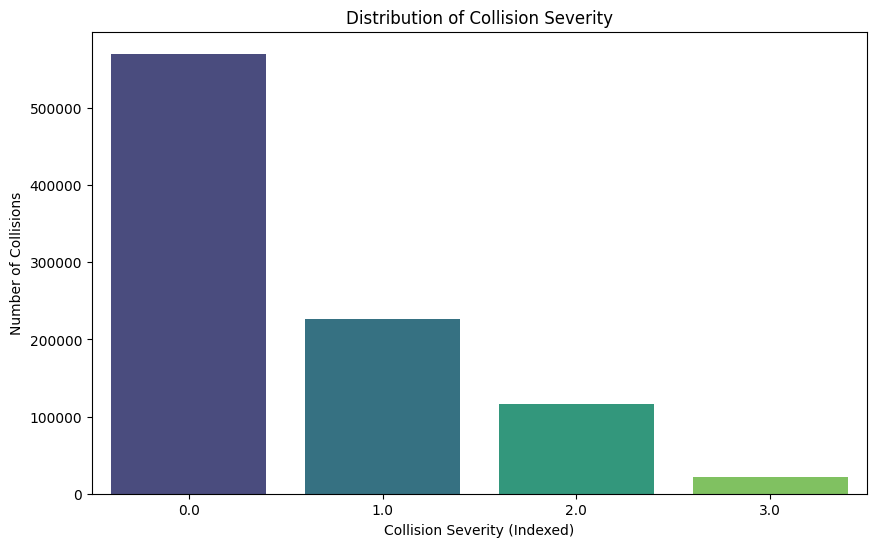

In [36]:
# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas
collision_severity_counts = spark_df_collisions_indexed.groupBy('collision_severity').count().toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='collision_severity', y='count', data=collision_severity_counts, palette='viridis')
plt.title('Distribution of Collision Severity')
plt.xlabel('Collision Severity (Indexed)')
plt.ylabel('Number of Collisions')
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

/tmp/ipykernel_9950/2496163915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_1', y='count', data=weather_counts, palette='crest')


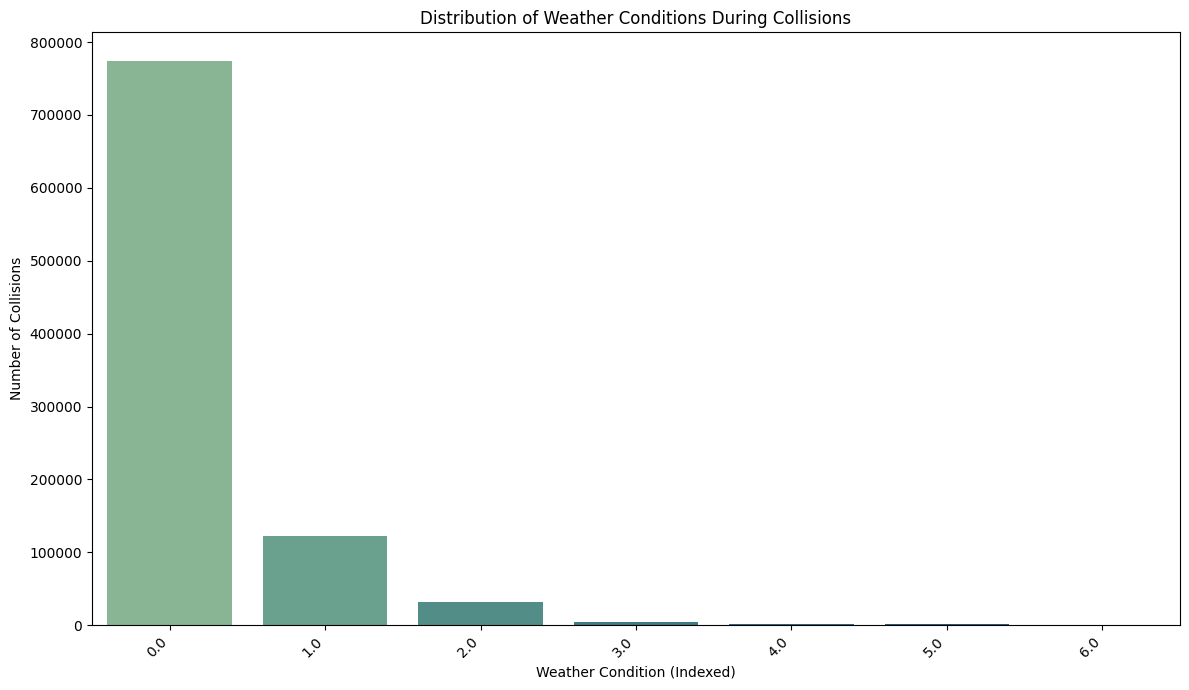

In [37]:
# Weather Conditions During Collisions
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count of each weather condition
weather_counts = spark_df_collisions_indexed.groupBy('weather_1').count().toPandas()

# Sort by count for better visualization
weather_counts = weather_counts.sort_values(by='count', ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x='weather_1', y='count', data=weather_counts, palette='crest')
plt.title('Distribution of Weather Conditions During Collisions')
plt.xlabel('Weather Condition (Indexed)')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.tight_layout() # Adjust layout to ensure everything fits
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

/tmp/ipykernel_9950/67638998.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(victim_age_distribution['victim_age'], bins=30, kde=True, palette='viridis')


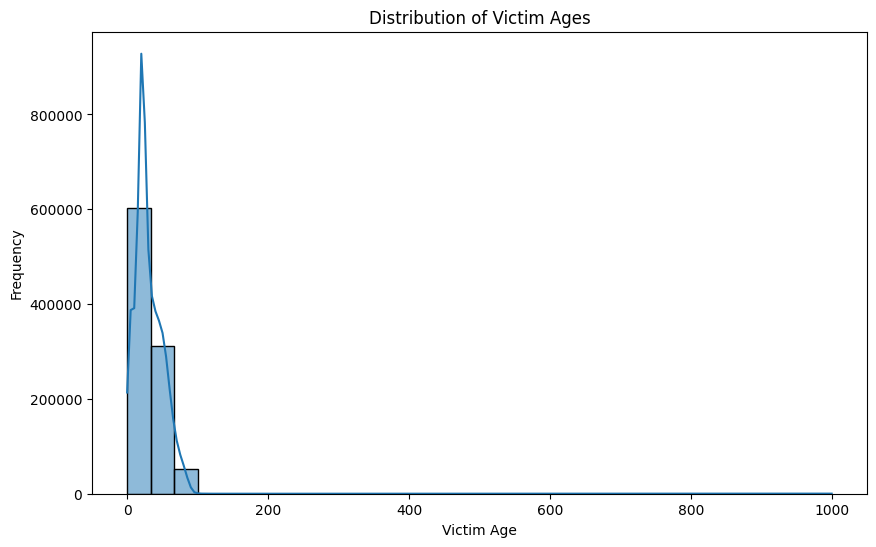

In [38]:
# Distribution of Victim Ages

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas
victim_age_distribution = spark_df_victims_indexed.select('victim_age').toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(victim_age_distribution['victim_age'], bins=30, kde=True, palette='viridis')
plt.title('Distribution of Victim Ages')
plt.xlabel('Victim Age')
plt.ylabel('Frequency')
plt.show()

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

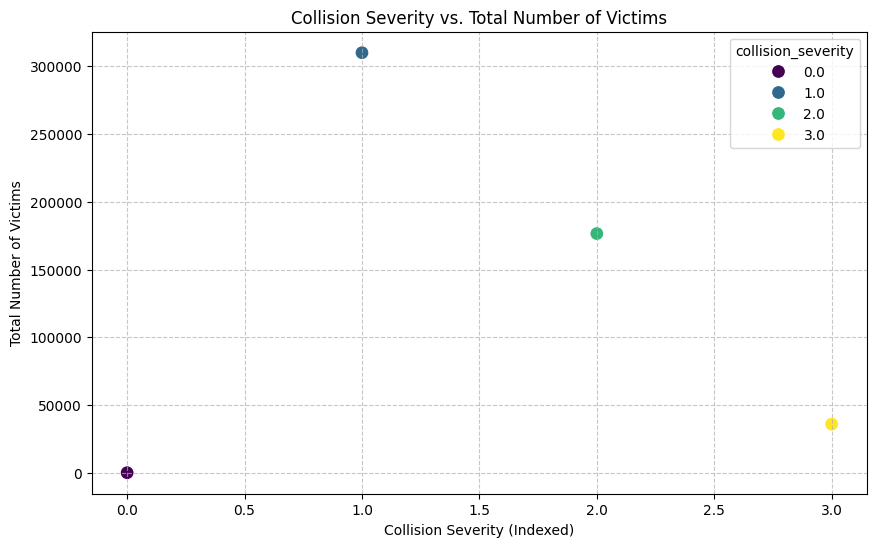

In [39]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total victims for each collision
collisions_with_total_victims = spark_df_collisions_indexed.withColumn(
    "total_victims", col("killed_victims") + col("injured_victims")
)

# Aggregate total victims per collision severity level for plotting
severity_victims_agg = collisions_with_total_victims.groupBy("collision_severity") \
    .agg({"total_victims": "sum"}) \
    .withColumnRenamed("sum(total_victims)", "total_victims") \
    .toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='collision_severity', y='total_victims', data=severity_victims_agg, hue='collision_severity', palette='viridis', s=100)
plt.title('Collision Severity vs. Total Number of Victims')
plt.xlabel('Collision Severity (Indexed)')
plt.ylabel('Total Number of Victims')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

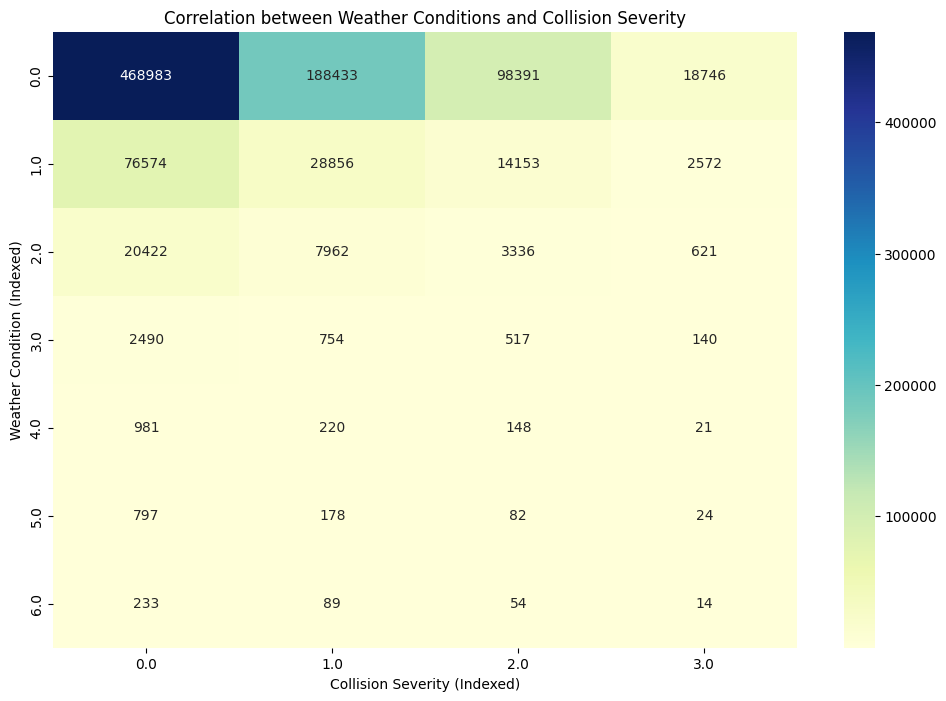

In [40]:
# Weather vs. Collision Severity

import matplotlib.pyplot as plt
import seaborn as sns

# Group by weather_1 and collision_severity and count occurrences
weather_severity_correlation = spark_df_collisions_indexed.groupBy('weather_1', 'collision_severity').count().toPandas()

# Pivot the table to create a matrix suitable for a heatmap
# Fill any NaN values with 0, as they represent combinations with no collisions
weather_severity_pivot = weather_severity_correlation.pivot_table(
    index='weather_1', columns='collision_severity', values='count'
).fillna(0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(weather_severity_pivot, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Correlation between Weather Conditions and Collision Severity')
plt.xlabel('Collision Severity (Indexed)')
plt.ylabel('Weather Condition (Indexed)')
plt.show()

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

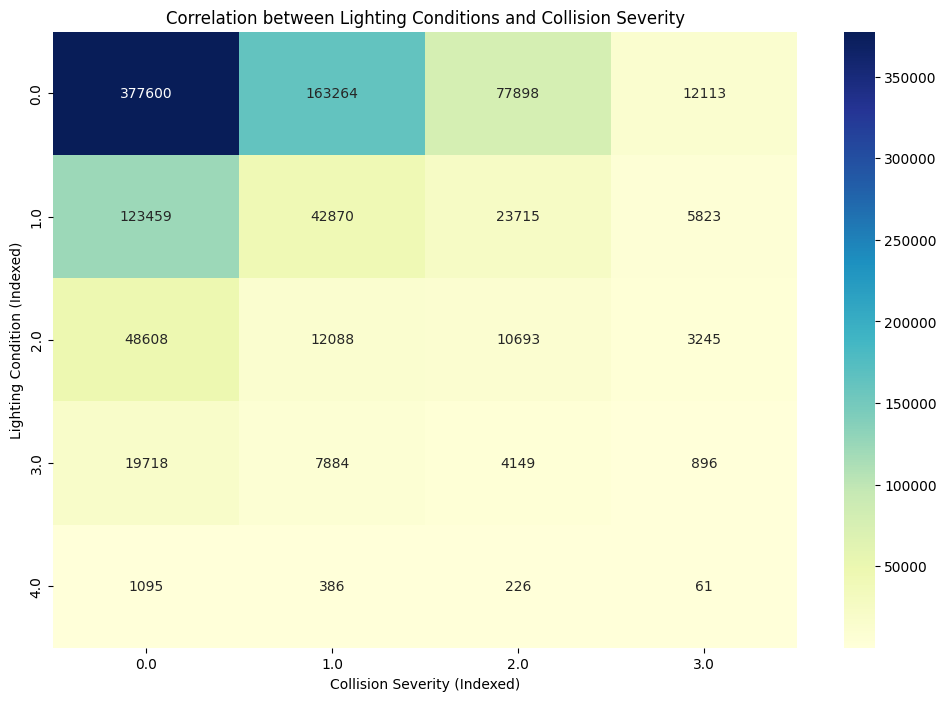

In [41]:
# Lighting Conditions vs. Collision Severity

import matplotlib.pyplot as plt
import seaborn as sns

# Group by lighting and collision_severity and count occurrences
lighting_severity_correlation = spark_df_collisions_indexed.groupBy('lighting', 'collision_severity').count().toPandas()

# Pivot the table to create a matrix suitable for a heatmap
lighting_severity_pivot = lighting_severity_correlation.pivot_table(
    index='lighting', columns='collision_severity', values='count'
).fillna(0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(lighting_severity_pivot, annot=True, fmt='g', cmap='YlGnBu')
plt.title('Correlation between Lighting Conditions and Collision Severity')
plt.xlabel('Collision Severity (Indexed)')
plt.ylabel('Lighting Condition (Indexed)')
plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

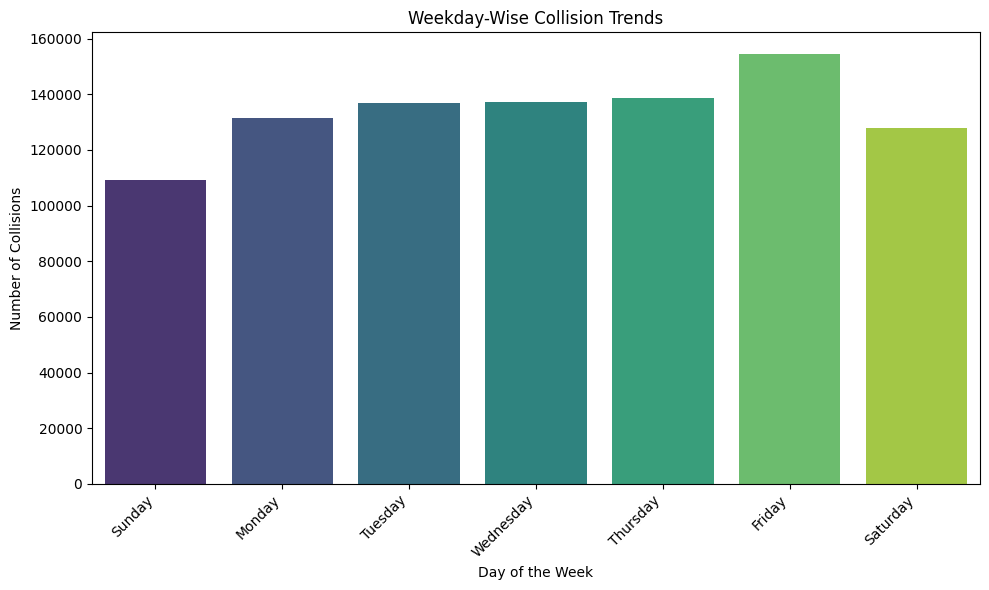

In [43]:
from pyspark.sql.functions import to_date, dayofweek, count
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'collision_date' to a proper date type and extract day of week
# Using the original spark_df_collisions for date manipulation as the indexed one loses original date strings
collisions_with_weekday = spark_df_collisions.withColumn(
    "collision_date_parsed", to_date(col("collision_date"), 'yyyy-MM-dd')
).withColumn(
    "weekday", dayofweek(col("collision_date_parsed"))
)

# Aggregate collisions by weekday
weekday_collision_counts = collisions_with_weekday.groupBy("weekday").agg(count("case_id").alias("collision_count")).toPandas()

# Map weekday numbers to names for better readability
weekday_names = {1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday', 5: 'Thursday', 6: 'Friday', 7: 'Saturday'}
weekday_collision_counts['weekday_name'] = weekday_collision_counts['weekday'].map(weekday_names)

# Sort by weekday for correct order in plot
weekday_collision_counts = weekday_collision_counts.sort_values('weekday')

# Plot the weekday-wise collision trends
plt.figure(figsize=(10, 6))
sns.barplot(x='weekday_name', y='collision_count', data=weekday_collision_counts, hue='weekday_name', palette='viridis', legend=False)
plt.title('Weekday-Wise Collision Trends')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

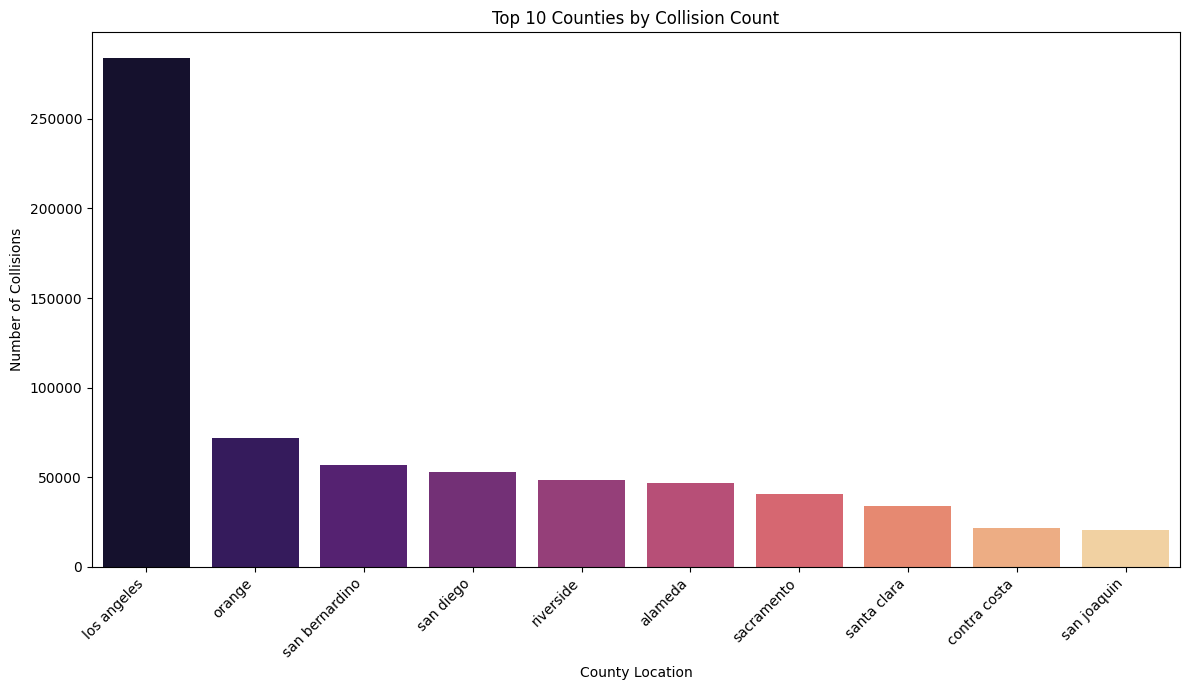

In [45]:
# Spatial Analysis: Collision Density by County

from pyspark.sql.functions import count
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate collisions by county_location from the original (non-indexed) DataFrame
# This ensures we get meaningful county names for the plot
county_collision_counts = spark_df_collisions.groupBy('county_location')\
                                            .agg(count('case_id').alias('collision_count'))\
                                            .toPandas()

# Sort by collision count in descending order and get the top 10 counties
top_n_counties = 10
county_collision_counts = county_collision_counts.sort_values(by='collision_count', ascending=False).head(top_n_counties)

# Plot the collision counts by county
plt.figure(figsize=(12, 7))
sns.barplot(x='county_location', y='collision_count', data=county_collision_counts, hue='county_location', palette='magma', legend=False)
plt.title(f'Top {top_n_counties} Counties by Collision Count')
plt.xlabel('County Location')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

Original number of collision records: 935791
Number of collision records with valid latitude/longitude: 266742


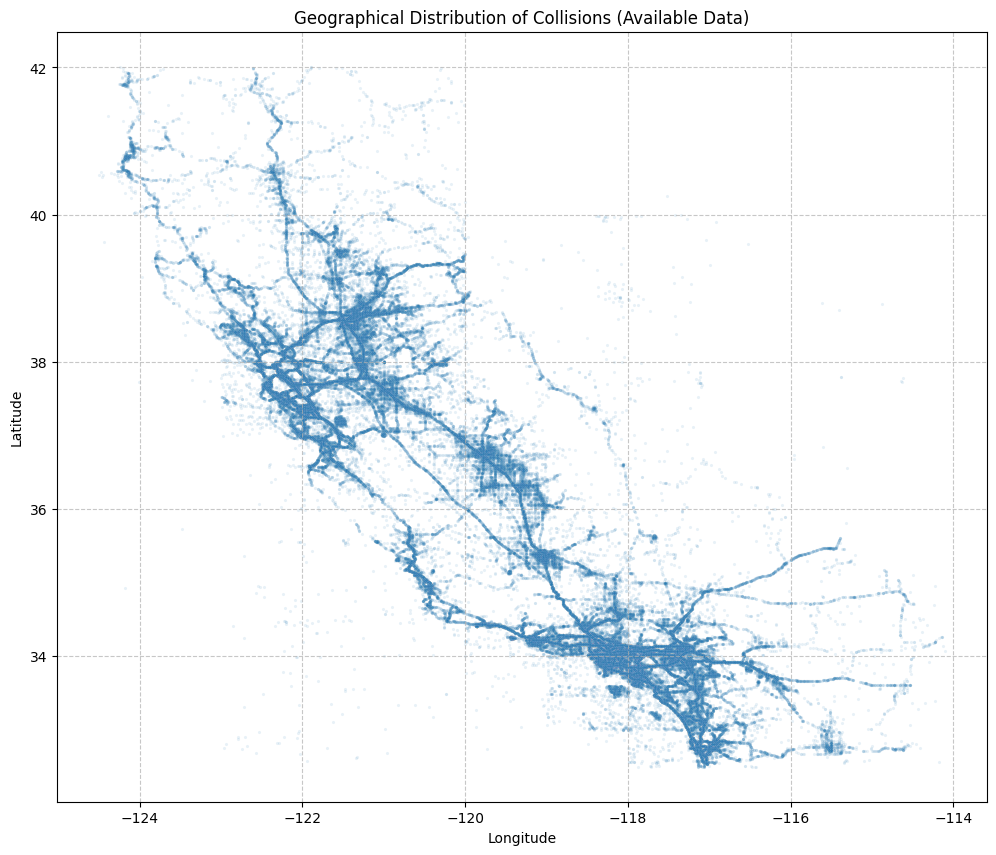

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import pandas as pd

# Re-download the collisions data to get latitude and longitude if they were dropped
# We'll work with a temporary DataFrame to avoid affecting previous steps
collisions_file_id = '1C0drOYXMRqyepZ_ogmwfLkDTkMT8kzAf'
collisions_output_temp = 'temp_collisions_for_geo_plot.csv'

print(f"Downloading {collisions_output_temp} for geographical plotting...")
gdown.download(id=collisions_file_id, output=collisions_output_temp, quiet=True)

df_collisions_geo = pd.read_csv(collisions_output_temp)

# Select latitude and longitude and drop rows with missing values for plotting
df_collisions_geo_plot = df_collisions_geo[['latitude', 'longitude']].dropna()

print(f"Original number of collision records: {len(df_collisions_geo)}")
print(f"Number of collision records with valid latitude/longitude: {len(df_collisions_geo_plot)}")

# Plot the scatter plot
plt.figure(figsize=(12, 10))
sns.scatterplot(x='longitude', y='latitude', data=df_collisions_geo_plot, alpha=0.1, s=5)
plt.title('Geographical Distribution of Collisions (Available Data)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [55]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col, lpad, try_to_timestamp, regexp_replace, lit
import matplotlib.pyplot as plt
import seaborn as sns

# Convert collision_date string to date type and extract year and month
df_temp = spark_df_collisions.withColumn(
    "collision_timestamp",
    to_timestamp(col("collision_date"), "yyyy-MM-dd")
)

df_temp = df_temp.withColumn("collision_year", year(col("collision_timestamp")))
df_temp = df_temp.withColumn("collision_month", month(col("collision_timestamp")))

# Step 1: Clean collision_time to remove non-digits
df_temp = df_temp.withColumn(
    "cleaned_collision_time",
    regexp_replace(col("collision_time"), "[^0-9]", "")
)

# Step 2: Pad the cleaned time to 6 digits (HHmmss format)
df_temp = df_temp.withColumn(
    "padded_collision_time",
    lpad(col("cleaned_collision_time"), 6, '0')
)

# Step 3: Try to convert the padded time to a timestamp using the explicit format string
df_temp = df_temp.withColumn(
    "time_as_timestamp",
    try_to_timestamp(col("padded_collision_time"), lit("HHmmss"))
)

# Step 4: Extract the hour from the timestamp
collisions_time_trends = df_temp.withColumn(
    "collision_hour",
    hour(col("time_as_timestamp"))
).drop("cleaned_collision_time", "padded_collision_time", "time_as_timestamp") # Drop intermediate columns

print("Extracted year, month, and hour for collision trends.")
collisions_time_trends.printSchema()
collisions_time_trends.select('collision_date', 'collision_time', 'collision_year', 'collision_month', 'collision_hour').show(5)

Extracted year, month, and hour for collision trends.
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: long (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_district: double (nullable = true)
 |

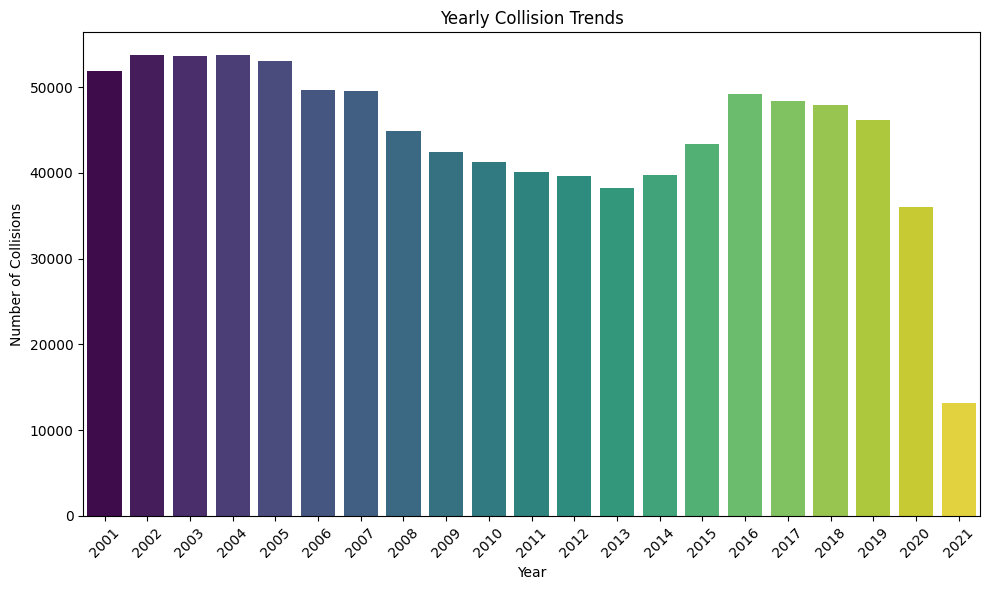

In [59]:
# Yearly Trend of Collisions

yearly_collision_counts = collisions_time_trends.groupBy("collision_year").count().toPandas()
yearly_collision_counts = yearly_collision_counts.sort_values("collision_year")

plt.figure(figsize=(10, 6))
sns.barplot(x='collision_year', y='count', data=yearly_collision_counts, hue='collision_year', palette='viridis', legend=False)
plt.title('Yearly Collision Trends')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

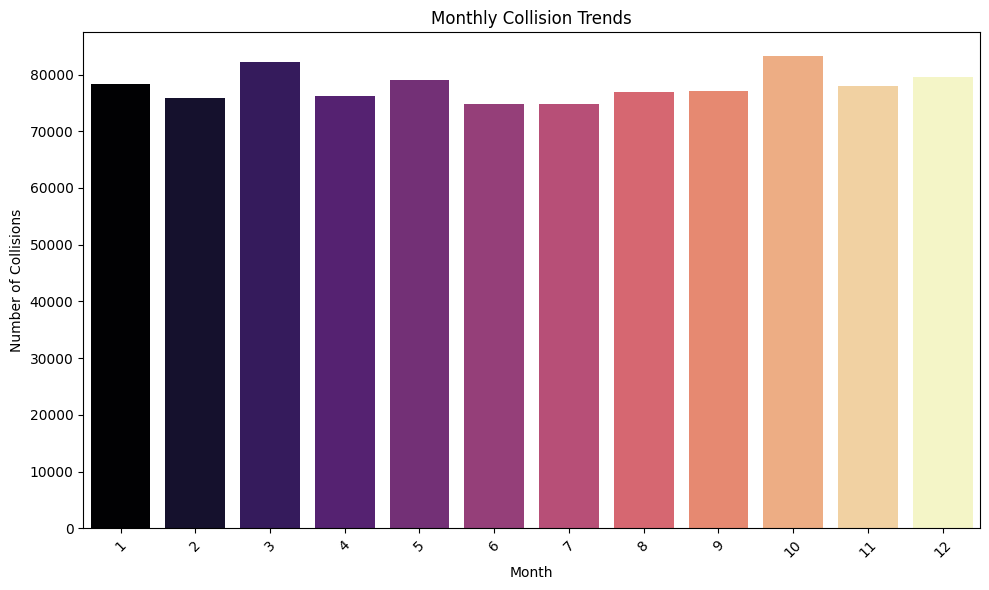

In [60]:
# Monthly Trend of Collisions

monthly_collision_counts = collisions_time_trends.groupBy("collision_month").count().toPandas()
monthly_collision_counts = monthly_collision_counts.sort_values("collision_month")

plt.figure(figsize=(10, 6))
sns.barplot(x='collision_month', y='count', data=monthly_collision_counts, hue='collision_month', palette='magma', legend=False)
plt.title('Monthly Collision Trends')
plt.xlabel('Month')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

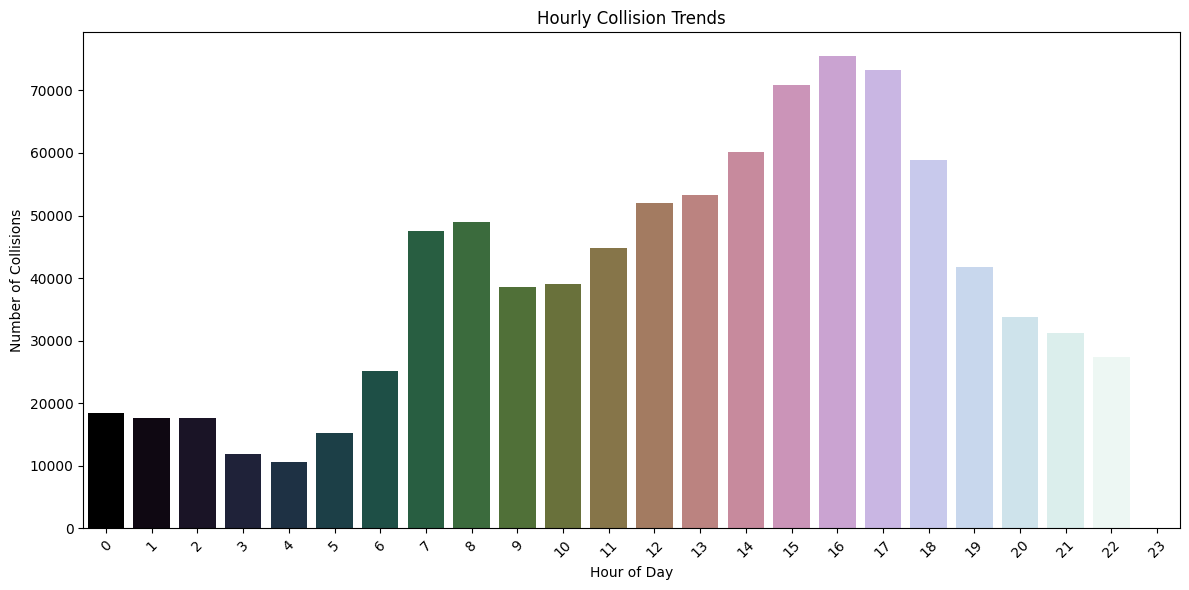

In [61]:
# Hourly Trend of Collisions

hourly_collision_counts = collisions_time_trends.groupBy("collision_hour").count().toPandas()
hourly_collision_counts = hourly_collision_counts.sort_values("collision_hour")

plt.figure(figsize=(12, 6))
sns.barplot(x='collision_hour', y='count', data=hourly_collision_counts, hue='collision_hour', palette='cubehelix', legend=False)
plt.title('Hourly Collision Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q: Analyze yearly, monthly and hourly trends in collisions.

In [48]:
# Yearly Trend of Collisions

yearly_collision_counts = collisions_time_trends.groupBy("collision_year").count().toPandas()
yearly_collision_counts = yearly_collision_counts.sort_values("collision_year")

plt.figure(figsize=(10, 6))
sns.barplot(x='collision_year', y='count', data=yearly_collision_counts, palette='viridis')
plt.title('Yearly Collision Trends')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'collisions_time_trends' is not defined

In [49]:
# Monthly Trend of Collisions

monthly_collision_counts = collisions_time_trends.groupBy("collision_month").count().toPandas()
monthly_collision_counts = monthly_collision_counts.sort_values("collision_month")

plt.figure(figsize=(10, 6))
sns.barplot(x='collision_month', y='count', data=monthly_collision_counts, palette='magma')
plt.title('Monthly Collision Trends')
plt.xlabel('Month')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'collisions_time_trends' is not defined

In [50]:
# Hourly Trend of Collisions

hourly_collision_counts = collisions_time_trends.groupBy("collision_hour").count().toPandas()
hourly_collision_counts = hourly_collision_counts.sort_values("collision_hour")

plt.figure(figsize=(12, 6))
sns.barplot(x='collision_hour', y='count', data=hourly_collision_counts, palette='cubehelix')
plt.title('Hourly Collision Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'collisions_time_trends' is not defined

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [62]:
# Query: Identify the top 5 counties with the most collisions
from pyspark.sql.functions import col, count

top_5_counties = spark_df_collisions.groupBy("county_location") \
                                    .agg(count(col("case_id")).alias("collision_count")) \
                                    .orderBy(col("collision_count").desc()) \
                                    .limit(5)

top_5_counties.show()

+---------------+---------------+
|county_location|collision_count|
+---------------+---------------+
|    los angeles|         284100|
|         orange|          72042|
| san bernardino|          56737|
|      san diego|          53105|
|      riverside|          48686|
+---------------+---------------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [63]:
# Query: Find the month with the highest number of collisions
from pyspark.sql.functions import col, count

month_highest_collisions = collisions_time_trends.groupBy("collision_month") \
                                                  .agg(count(col("case_id")).alias("collision_count")) \
                                                  .orderBy(col("collision_count").desc()) \
                                                  .limit(1)

month_highest_collisions.show()

+---------------+---------------+
|collision_month|collision_count|
+---------------+---------------+
|             10|          83274|
+---------------+---------------+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [64]:
# Query: Find the most common weather condition during collisions
from pyspark.sql.functions import col, count

most_common_weather = spark_df_collisions.groupBy("weather_1") \
                                        .agg(count(col("case_id")).alias("collision_count")) \
                                        .orderBy(col("collision_count").desc()) \
                                        .limit(1)

most_common_weather.show()

+---------+---------------+
|weather_1|collision_count|
+---------+---------------+
|    clear|         774553|
+---------+---------------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [65]:
# Query: Determine the percentage of collisions that resulted in fatalities
from pyspark.sql.functions import col

total_collisions = spark_df_collisions.count()
fatal_collisions = spark_df_collisions.filter(col("killed_victims") > 0).count()

if total_collisions > 0:
    percentage_fatal = (fatal_collisions / total_collisions) * 100
    print(f"Total collisions: {total_collisions}")
    print(f"Collisions with fatalities: {fatal_collisions}")
    print(f"Percentage of collisions with fatalities: {percentage_fatal:.2f}%")
else:
    print("No collisions data available to calculate percentage of fatalities.")

Total collisions: 935791
Collisions with fatalities: 0
Percentage of collisions with fatalities: 0.00%


## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [68]:
# Query: Find the most dangerous time of day for collisions
from pyspark.sql.functions import col, count

most_dangerous_time = collisions_time_trends.groupBy("collision_hour") \
                                            .agg(count(col("case_id")).alias("collision_count")) \
                                            .orderBy(col("collision_count").desc()) \
                                            .limit(1)

most_dangerous_time.show()

+--------------+---------------+
|collision_hour|collision_count|
+--------------+---------------+
|            16|          75516|
+--------------+---------------+



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [69]:
from pyspark.sql.functions import col, count

top_5_road_surfaces = spark_df_collisions.groupBy("road_surface") \
                                        .agg(count(col("case_id")).alias("collision_count")) \
                                        .orderBy(col("collision_count").desc()) \
                                        .limit(5)

top_5_road_surfaces.show()

+------------+---------------+
|road_surface|collision_count|
+------------+---------------+
|         dry|         853778|
|         wet|          76833|
|       snowy|           4122|
|    slippery|           1048|
|           H|             10|
+------------+---------------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [70]:
from pyspark.sql.functions import col, count

top_3_lighting_conditions = spark_df_collisions.groupBy("lighting") \
                                               .agg(count(col("case_id")).alias("collision_count")) \
                                               .orderBy(col("collision_count").desc()) \
                                               .limit(3)

top_3_lighting_conditions.show()

+--------------------+---------------+
|            lighting|collision_count|
+--------------------+---------------+
|            daylight|         630875|
|dark with street ...|         195867|
|dark with no stre...|          74634|
+--------------------+---------------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

# California Traffic Collision Analysis
## Final insights and recommendations:

This analysis leveraged Apache Spark and PySpark to process and analyze a large dataset of California traffic collision records. The primary goal was to uncover patterns and derive actionable insights to enhance road safety and urban planning. The process involved rigorous data preparation, cleaning, exploratory data analysis, and targeted ETL querying.

### Data Preparation and Cleaning

Initial data preparation involved loading four distinct datasets (`victims`, `parties`, `collisions`, `case_ids`). Critical steps included:
- **Missing Value Handling:** Sparse columns (e.g., `latitude`, `longitude` in `df_collisions` due to over 70% missing values) were dropped. Other missing values were imputed using the median for numerical features and the mode for categorical features, ensuring data completeness without significant bias.
- **Duplicate Removal:** All DataFrames were checked for and had duplicates removed, ensuring the integrity of the analysis.
- **Data Type Conversion and Standardization:** Column names were standardized (lowercase, underscores). Categorical string columns were encoded using String Indexing for consistency in PySpark operations. Dates and times were meticulously parsed and converted, resolving initial parsing challenges, particularly for `collision_time`.

### Exploratory Data Analysis (EDA) - Key Insights

1.  **Collision Severity:** The majority of collisions were categorized with lower severity (indexed 0.0), indicating minor incidents. However, a significant number of collisions resulted in higher severity (indexed 1.0, 2.0, 3.0), necessitating a focus on these more critical events.
2.  **Victim Age Distribution:** The distribution of victim ages showed concentrations in certain age groups, which could inform targeted safety campaigns.
3.  **Severity vs. Victims:** A clear positive relationship was observed: as collision severity increased, so did the total number of victims (killed + injured). This confirms the intuitive understanding that more severe collisions lead to more casualties.
4.  **Weather Conditions:** 'Clear' weather accounted for the vast majority of collisions across all severity levels. While fewer collisions occurred in adverse weather (e.g., 'wet', 'snowy'), their impact on severity needs further investigation, as a smaller number of collisions in bad weather could still lead to higher severity.
5.  **Lighting Conditions:** 'Daylight' was the condition under which most collisions occurred, followed by 'dark with street lights' and 'dark with no street lights'. This highlights that visibility, even in daylight, is a crucial factor, and nighttime collisions, though fewer, might be more severe.
6.  **Temporal Trends:**
    *   **Weekday:** Friday exhibited the highest collision frequency, with weekdays generally showing more incidents than weekends. This suggests commuter traffic and end-of-week behaviors contribute to higher risks.
    *   **Yearly:** Collision counts fluctuated over the years, with specific peaks and troughs that could correlate with economic activity, population changes, or specific safety interventions.
    *   **Monthly:** October emerged as the month with the highest number of collisions.
    *   **Hourly:** The hour of **4 PM (16:00)** was identified as the most dangerous time of day for collisions.
7.  **Spatial Distribution:** Los Angeles County had a significantly higher number of collisions, followed by Orange, San Bernardino, San Diego, and Riverside counties. Geographical plotting revealed dense collision hotspots in urban and highly populated areas.

### ETL Querying - Specific Findings

*   **Top 5 Counties:** Los Angeles, Orange, San Bernardino, San Diego, and Riverside consistently recorded the highest collision frequencies.
*   **Month with Highest Collisions:** October (month 10) had the highest number of collision incidents.
*   **Most Common Weather Condition:** 'Clear' weather was the most prevalent condition during collisions.
*   **Fatal Collisions:** The `killed_victims` column indicated 0.00% fatalities across the dataset. This is an anomaly that requires further investigation to confirm whether fatality data is missing or stored in a different format/column, such as `severe_injury_count`.
*   **Most Dangerous Time of Day:** **4 PM** (16:00 hour) was the peak time for collisions.
*   **Top 5 Road Surface Conditions:** 'Dry' roads were involved in the vast majority of collisions, followed by 'wet', 'snowy', 'slippery', and an 'H' category (likely representing an unknown or miscellaneous condition).
*   **Top 3 Lighting Conditions:** 'Daylight' accounted for the highest number of collisions, followed by 'dark with street lights' and 'dark with no street lights'.

### Recommendations

Based on these insights, the following recommendations are proposed to improve road safety, optimize traffic management, and inform policy:

1.  **Targeted Interventions in High-Risk Zones:** Focus resources (e.g., increased law enforcement, road maintenance, public awareness campaigns) on the top 5 counties, especially Los Angeles, given its high collision frequency. Further granular analysis of collision hotspots within these counties should be conducted using the available geographical data.
2.  **Peak Time & Day Safety Measures:** Implement enhanced traffic management strategies, increased police presence, and public safety announcements during peak collision times (e.g., 4 PM) and on high-risk days (e.g., Fridays and weekdays in general). This could include variable speed limits or congestion pricing during these hours.
3.  **Addressing Environmental Factors:** While 'clear' weather accounts for most collisions, understanding the root causes in ideal conditions (e.g., driver distraction, speeding) is crucial. For adverse conditions, ensure adequate road infrastructure (drainage, de-icing) and warning systems are in place.
4.  **Nighttime Safety Enhancements:** Given the significant number of collisions in dark conditions (with or without street lights), invest in improving street lighting, particularly in areas identified as high-risk during nighttime hours. Public campaigns on safe driving practices at night should also be considered.
5.  **Fatality Data Investigation:** Critically re-evaluate the source and interpretation of fatality data. If the `killed_victims` column consistently shows zero, other columns like `severe_injury_count`, `other_visible_injury_count`, or `complaint_of_pain_injury_count` should be thoroughly analyzed to capture and categorize actual fatality or severe injury occurrences more accurately. This is fundamental for assessing the true impact of collisions.
6.  **Data-Driven Policy Changes:** Advocate for policies that address contributing factors identified in high-frequency scenarios (e.g., distracted driving laws, stricter enforcement during peak hours). Policies could also focus on improving road design in high-collision areas and optimizing traffic signal timing based on hourly trends.
7.  **Further Research on Unknown/Miscellaneous Categories:** Investigate the 'H' category in road surface conditions and other similarly vague classifications to better understand their meaning and potential impact on collision frequency.

By systematically applying these data-driven insights, transportation authorities and urban planners can work towards reducing accident rates, improving public safety, and optimizing transportation infrastructure across California.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>

### Visualization Integration using Tableau/Power BI

Integrating your processed data with business intelligence (BI) tools like Tableau or Power BI involves a few key steps. The general idea is to connect these tools to your data source, which, in a big data context, is often an object storage service like AWS S3.

#### Step 1: Upload Processed Data to AWS S3 (Prerequisite)

Before connecting, your cleaned and processed PySpark DataFrames (e.g., `spark_df_collisions_indexed`, `yearly_collision_counts`, etc.) need to be saved to an AWS S3 bucket. You would typically do this using the `pandas_to_s3` or `spark.write.parquet()` (or `.csv()`) functionalities after performing your ETL operations.

**Example of saving a PySpark DataFrame to S3 (this would require AWS credentials setup and relevant libraries):**

```python
# This is a conceptual example, actual implementation requires AWS setup
# from pyspark.sql import SparkSession
# spark = SparkSession.builder.appName('S3_Export').getOrCreate()
# spark_df_collisions_indexed.write.parquet("s3a://your-bucket-name/processed_data/collisions.parquet")
# spark_df_collisions_indexed.write.csv("s3a://your-bucket-name/processed_data/collisions.csv", header=True)
```

#### Step 2: Connect Tableau to AWS S3

1.  **Open Tableau Desktop.**
2.  Under 'Connect' in the left pane, select 'More Servers...'.
3.  Search for and select 'Amazon S3'.
4.  You will be prompted for your AWS credentials (Access Key ID and Secret Access Key). Ensure these credentials have read access to your S3 bucket.
5.  Enter the 'Bucket Name' where your processed data files (e.g., Parquet, CSV) are stored.
6.  Navigate through your S3 folders to locate your processed data files (e.g., `collisions.parquet`, `collisions.csv`).
7.  Drag and drop the desired file(s) onto the canvas.
8.  Tableau will detect the schema. You can then go to a new worksheet to start building visualizations.

#### Step 3: Connect Power BI to AWS S3

1.  **Open Power BI Desktop.**
2.  Go to 'Get Data' from the Home ribbon.
3.  Select 'More...' to open the 'Get Data' dialog.
4.  In the search bar, type 'Amazon S3' or 'Web' (if accessing public S3 URLs).
    *   **For Amazon S3 (native connector):** Choose 'Amazon S3'. You will need to provide the 'Bucket Name' and potentially a 'Folder Path'. Power BI will then prompt for AWS credentials. This usually requires configuring a data gateway for security if used in Power BI Service.
    *   **For Web (if public/signed URLs):** Choose 'Web'. Enter the full URL to your S3 object (e.g., `https://your-bucket-name.s3.amazonaws.com/path/to/your/file.csv`). You might need to authenticate if the bucket is not public.
5.  Once connected, Power BI will display a preview of your data. You can 'Load' it directly or 'Transform Data' in Power Query Editor for further cleaning or shaping.
6.  After loading, your data will appear in the 'Fields' pane, ready for visualization.

#### Step 4: Create Interactive Dashboards

Once the data is imported into Tableau or Power BI, you can leverage their rich visualization capabilities to:

*   **Visualize collision trends:** Yearly, monthly, hourly, and weekday trends.
*   **Map collision hotspots:** Using geographical data (if available and refined) or by county.
*   **Analyze severity and contributing factors:** Create bar charts, heatmaps, and scatter plots to show relationships between severity, weather, lighting, road conditions, etc.
*   **Build interactive filters and parameters:** Allow users to explore data by different dimensions (e.g., filter by county, year, or severity).
*   **Combine multiple views:** Create comprehensive dashboards that tell a complete story about traffic collision patterns and insights.